# Customer Segmentation and Churn Analysis

Objective

The objective of this analysis is to understand customer churn patterns and identify customer segments with a higher risk of leaving the service. The analysis uses customer demographics, tenure, services, contract type, payment method, and billing information to derive actionable retention insights.

## Data Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [2]:
# Load dataset
df = pd.read_csv("E:\\Projects\\Customer_Segmentation\\Telco_Customer_Churn_Dataset.csv")

df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
print(f"No. of Rows: {df.shape[0]} \nNo. of Columns: {df.shape[1]}")

df.info()

No. of Rows: 7043 
No. of Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pape

Most of the columns are categorical and TotalCharges requires conversion to numeric

In [4]:
#check for null values
pd.isnull(df).sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
#check for duplicated values
df.duplicated().sum()

np.int64(0)

In [6]:
#check for duplicated values for customerID
df['customerID'].duplicated().sum()

np.int64(0)

In [7]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

## Data Pre-Processing

Data Cleaning

The dataset was checked for missing values and duplicate records before analysis.

The following preprocessing steps were performed:

* Standardized column names to lowercase.
* Converted `totalcharges` from object to numeric.
* Checked for missing values.
* Checked for duplicate records and duplicate customer IDs.
* Standardized categorical values where required.

These steps ensured that the dataset was consistent and suitable for exploratory analysis.


In [8]:
df.columns = df.columns.str.lower()
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [9]:
# change data type
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

In [10]:
df['totalcharges'].isnull().sum()

np.int64(11)

In [11]:
# Fill missing TotalCharges with median
df['totalcharges']= df['totalcharges'].fillna(df['totalcharges'].median())

In [12]:
#Changing SeniorCitizen values from 0,1 to yes & no
def convert_value(value):
    if value == 1 :
        return "yes"
    else :
        return "no"

df['seniorcitizen']=df['seniorcitizen'].apply(convert_value)

In [13]:
df['paymentmethod'] = df['paymentmethod'].replace({
    'Bank transfer (automatic)': 'Bank transfer',
    'Credit card (automatic)': 'Credit card'
})

In [14]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer,42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   object 
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


## EDA

Exploratory analysis was performed to understand the overall churn distribution and identify patterns in customer tenure and billing behavior.

Key variables analyzed included:

* Churn
* Tenure
* Monthly charges
* Total charges
* Contract type
* Payment method
* Customer demographics

The overall churn rate is approximately 26.5%, indicating that customer retention is an important business concern.


In [16]:
df.describe()

,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


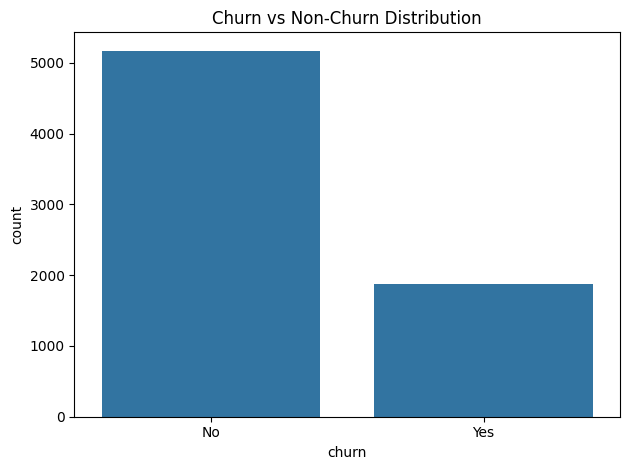

In [20]:
#Churn Distribution
sns.countplot(x='churn', data=df)
plt.title("Churn vs Non-Churn Distribution")
plt.tight_layout()
plt.savefig("E:/Projects/Customer_Segmentation/images/01_Churn_vs_Non-Churn_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

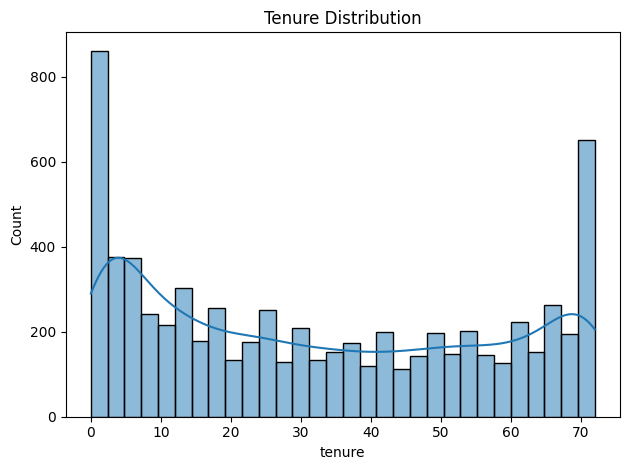

In [21]:
#Tenure Distribution
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Tenure Distribution")
plt.tight_layout()
plt.savefig("E:/Projects/Customer_Segmentation/images/02_Tenure_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

**Key Insight:** Churn is concentrated among customers with shorter tenure, particularly during the first 12 months. Customers who remain longer tend to show greater retention, making the early customer lifecycle an important period for retention efforts.


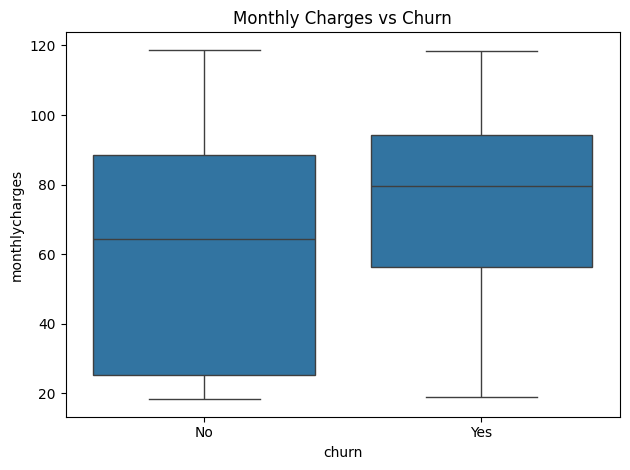

In [22]:
#Monthly Charges Boxplot
sns.boxplot(x='churn', y='monthlycharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.tight_layout()
plt.savefig("E:/Projects/Customer_Segmentation/images/03_Monthly_Charges_vs_Churn.png", dpi=300, bbox_inches='tight')
plt.show()

**Key Insight:** Customers with higher monthly charges show a noticeable concentration of churn. This suggests that pricing and perceived value should be considered when designing retention strategies.

## Customer Segmentation

Customers were segmented based on tenure to understand how customer lifecycle stage relates to churn.

The following segments were created:

* **0–12 months:** Short-term customers
* **13–36 months:** Mid-term customers
* **37+ months:** Long-term customers

Churn rates and average monthly charges were then compared across these segments.


In [23]:
#Create Tenure Categories
bins = [0, 12, 36, 72]
labels = ['0-12 Months', '13-36 Months', '37+ Months']

df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels)

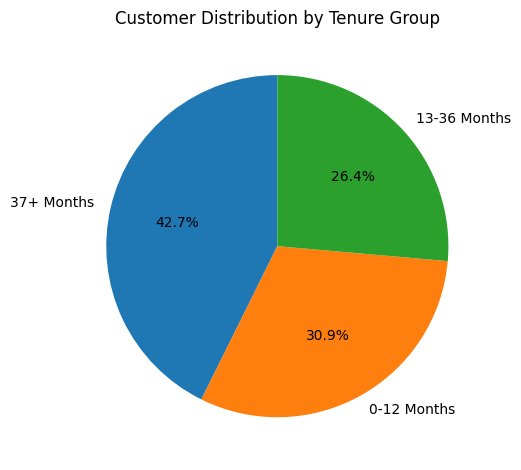

In [24]:
#Pie Chart (Tenure Distribution)
tenure_counts = df['tenure_group'].value_counts()

plt.pie(tenure_counts, labels=tenure_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Customer Distribution by Tenure Group")
plt.tight_layout()
plt.savefig("E:/Projects/Customer_Segmentation/images/04_Customer_Distribution_by_Tenure_Group.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_3056\689812283.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_charges = df.groupby('tenure_group')['monthlycharges'].mean()


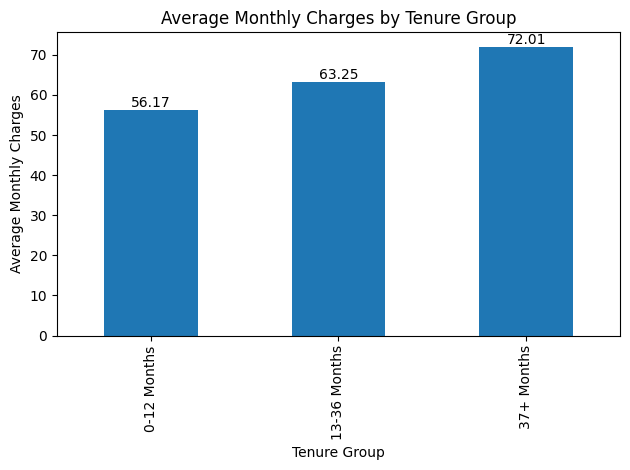

In [25]:
#Clustered Bar Chart (Monthly Charges)
avg_charges = df.groupby('tenure_group')['monthlycharges'].mean()

avg_charges.plot(kind='bar')
plt.title("Average Monthly Charges by Tenure Group")
plt.ylabel("Average Monthly Charges")
plt.xlabel("Tenure Group")

for index, value in enumerate(avg_charges):
    plt.text(index, value, round(value,2), ha='center', va='bottom')

plt.tight_layout()
plt.savefig("E:/Projects/Customer_Segmentation/images/05_Average_Monthly_Charges_by_Tenure_Group.png", dpi=300, bbox_inches='tight')
plt.show()

## Advanced Churn Analysis

Churn patterns were further analyzed across customer demographics, contract types, and payment methods.

The analysis focused on identifying customer characteristics associated with higher or lower churn rates and determining which segments may require targeted retention strategies.

C:\Users\DELL\AppData\Local\Temp\ipykernel_3056\1338053815.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_tenure = df.groupby('tenure_group')['churn'].value_counts(normalize=True).unstack()


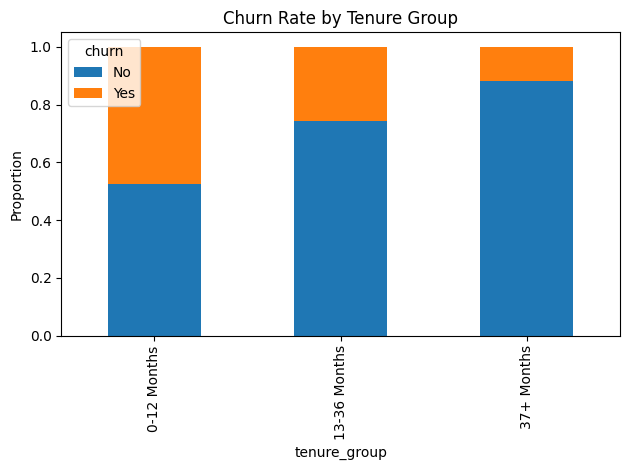

In [26]:
#Churn Rate by Tenure Group
churn_tenure = df.groupby('tenure_group')['churn'].value_counts(normalize=True).unstack()

churn_tenure.plot(kind='bar', stacked=True)
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Proportion")
plt.tight_layout()
plt.savefig("E:/Projects/Customer_Segmentation/images/06_Churn_Rate_by_Tenure_Group.png", dpi=300, bbox_inches='tight')
plt.show()

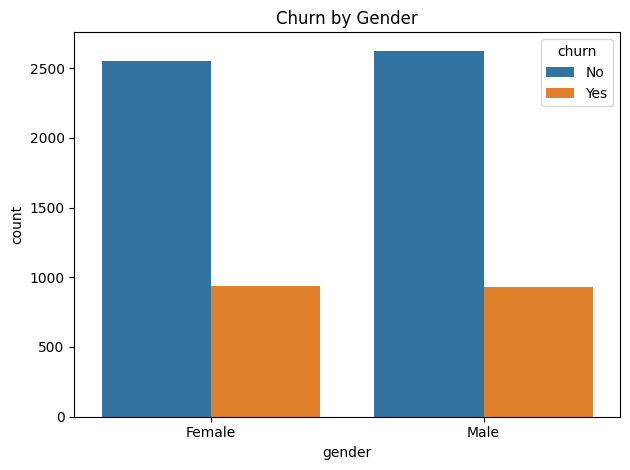

In [27]:
#Churn by Gender
sns.countplot(x='gender', hue='churn', data=df)
plt.title("Churn by Gender")
plt.tight_layout()
plt.savefig("images/07_Churn_by_Gender.png", dpi=300, bbox_inches='tight')
plt.show()

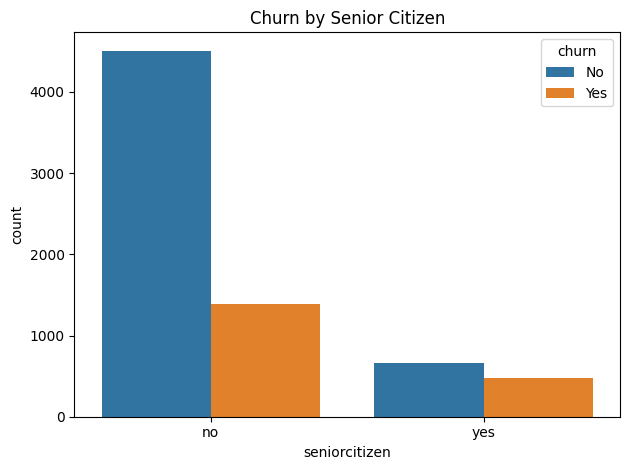

In [28]:
#Churn by Senior Citizen
sns.countplot(x='seniorcitizen', hue='churn', data=df)
plt.title("Churn by Senior Citizen")
plt.tight_layout()
plt.savefig("images/08_Churn by Senior Citizen.png", dpi=300, bbox_inches='tight')
plt.show()

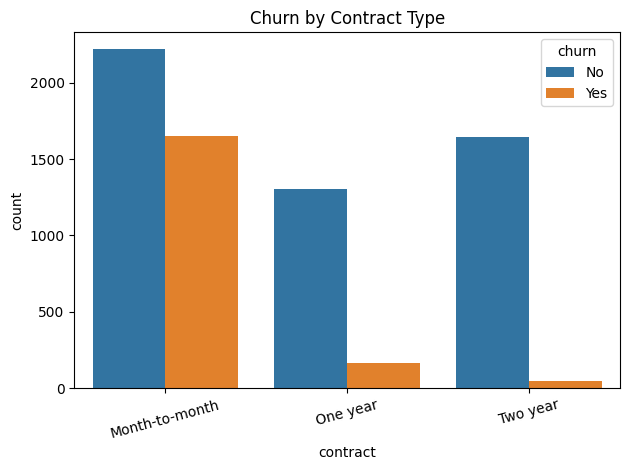

In [29]:
#Churn by Contract Type
sns.countplot(x='contract', hue='churn', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("images/09_Churn_by_Contract_Type.png", dpi=300, bbox_inches='tight')
plt.show()

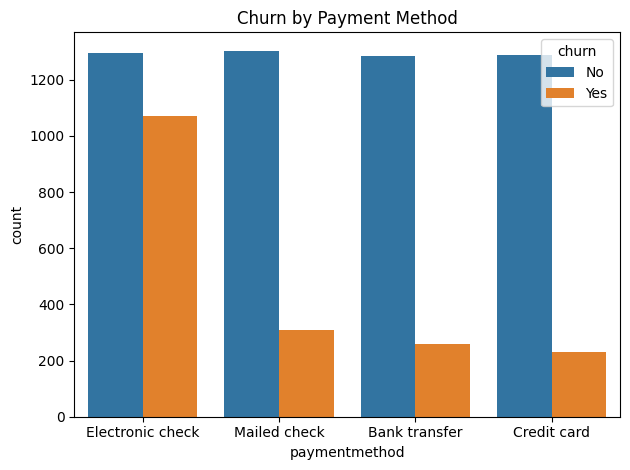

In [30]:
#Churn by Payment Method
sns.countplot(x='paymentmethod', hue='churn', data=df)
plt.title("Churn by Payment Method")
plt.tight_layout()
plt.savefig("E:/Projects/Customer_Segmentation/images/10_Churn_by_Payment_Method.png", dpi=300, bbox_inches='tight')
plt.show()

## Key Findings

* Month-to-month customers exhibit the highest churn rate.
* Customers with shorter tenure, particularly within the first year, are more likely to churn.
* Electronic-check users show higher churn compared with customers using automatic payment methods.
* Higher monthly-charge segments show a noticeable concentration of churn.
* Gender shows relatively limited differences in churn compared with contract type, tenure, and payment method.

## Business Recommendations

Based on these patterns, retention efforts should focus on:

* Improving onboarding and engagement during the first year.
* Encouraging customers to move from month-to-month to longer-term contracts.
* Providing targeted retention offers to higher-risk customer segments.
* Promoting convenient automatic payment methods.
* Reviewing pricing and perceived value for higher-charge customers.